Raw shape: (2000, 17)
Raw data sample:


,order_id,customer_id,age,gender,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,unit_price,quantity,purchase_frequency,product_name,category,Ratings,"Churn label yes=1, no=0"
0,ORD5000,CUST1000,39,Female,PROD200,Canada,01-07-2021,2/21/2023,0,active,78.21,5,37,Football,Sports,4.2,1
1,ORD5001,CUST1001,61,Female,PROD201,USA,10/19/2020,12-08-2021,0,active,64.02,8,35,Refrigerator,Home,4.0,1
2,ORD5002,CUST1002,26,Female,PROD202,Pakistan,06-10-2023,09-04-2023,3,cancelled,604.14,2,44,Hoodie,Clothing,3.9,1
3,ORD5003,CUST1003,54,Male,PROD203,India,7/30/2023,2/20/2024,4,paused,84.66,4,1,Conditioner,Beauty,4.2,1
4,ORD5004,CUST1004,50,Male,PROD204,India,12-09-2020,9/14/2024,0,active,62.66,7,35,Smartwatch,Electronics,4.2,1



Data types:


,0
order_id,object
customer_id,object
age,int64
gender,object
product_id,object
country,object
signup_date,object
last_purchase_date,object
cancellations_count,int64
subscription_status,object



Aggregated customer features sample:


,CustomerID,Frequency,FirstPurchaseDate,LastPurchaseDate,Monetary_sum,Monetary_avg,Recency_days,churn_15d
0,CUST1000,1,2023-02-21,2023-02-21,391.05,391.05,912.0,1
1,CUST1001,0,NaT,NaT,512.16,512.16,NaN,0
2,CUST1002,0,NaT,NaT,1208.28,1208.28,NaN,0
3,CUST1003,1,2024-02-20,2024-02-20,338.64,338.64,548.0,1
4,CUST1004,1,2024-09-14,2024-09-14,438.62,438.62,341.0,1


Snapshot date used: 2025-08-21 00:00:00

Churn distribution in aggregated data:
churn_15d
1    0.598
0    0.402
Name: proportion, dtype: float64

Modeling table shape: (2000, 18)
Modeling table sample:


,CustomerID,Frequency,FirstPurchaseDate,LastPurchaseDate,Monetary_sum,Monetary_avg,Recency_days,churn_15d,age,gender,country,signup_date,cancellations_count,subscription_status,unit_price,quantity,purchase_frequency,Ratings
0,CUST1000,1,2023-02-21,2023-02-21,391.05,391.05,912.0,1,39,Female,Canada,01-07-2021,0,active,78.21,5,37,4.2
1,CUST1001,0,NaT,NaT,512.16,512.16,592.5,0,61,Female,USA,10/19/2020,0,active,64.02,8,35,4.0
2,CUST1002,0,NaT,NaT,1208.28,1208.28,592.5,0,26,Female,Pakistan,06-10-2023,3,cancelled,604.14,2,44,3.9
3,CUST1003,1,2024-02-20,2024-02-20,338.64,338.64,548.0,1,54,Male,India,7/30/2023,4,paused,84.66,4,1,4.2
4,CUST1004,1,2024-09-14,2024-09-14,438.62,438.62,341.0,1,50,Male,India,12-09-2020,0,active,62.66,7,35,4.2



Target variable already has two classes. Proceeding without generating synthetic data.

Introducing 5.0% label noise...
Flipped 59 churned labels to not churned.
Flipped 40 not churned labels to churned.
Noisy combined target distribution:
churn_15d
1    0.5885
0    0.4115
Name: proportion, dtype: float64

Numeric features for modeling: ['Frequency', 'Monetary_sum', 'Monetary_avg', 'Recency_days', 'age', 'Ratings', 'cancellations_count', 'quantity', 'purchase_frequency', 'unit_price']
Categorical features for modeling: ['gender', 'country', 'signup_date', 'subscription_status']

Noisy Combined Train shape: (1600, 14) Noisy Combined Test shape: (400, 14)
Noisy Combined y_train distribution: churn_15d
1    0.58875
0    0.41125
Name: proportion, dtype: float64
Noisy Combined y_test distribution: churn_15d
1    0.5875
0    0.4125
Name: proportion, dtype: float64

Noisy Combined Train preprocessed shape: (1600, 864)
Noisy Combined Test preprocessed shape: (400, 864)

Training XGBoost model

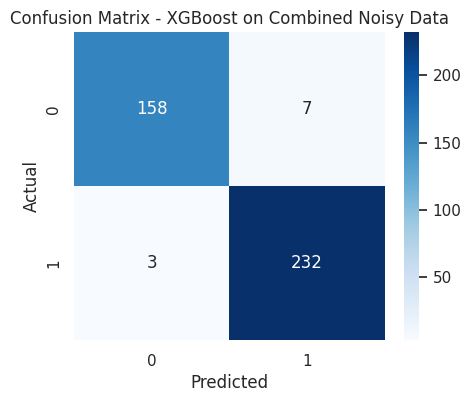

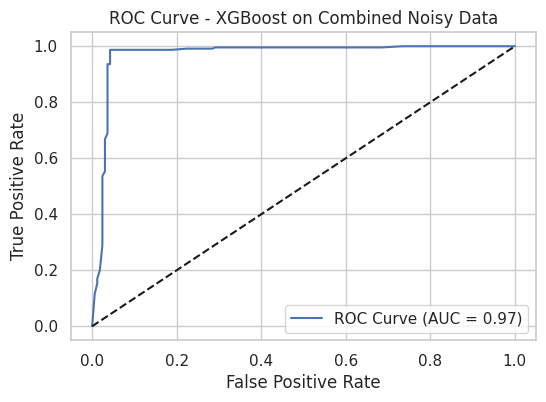

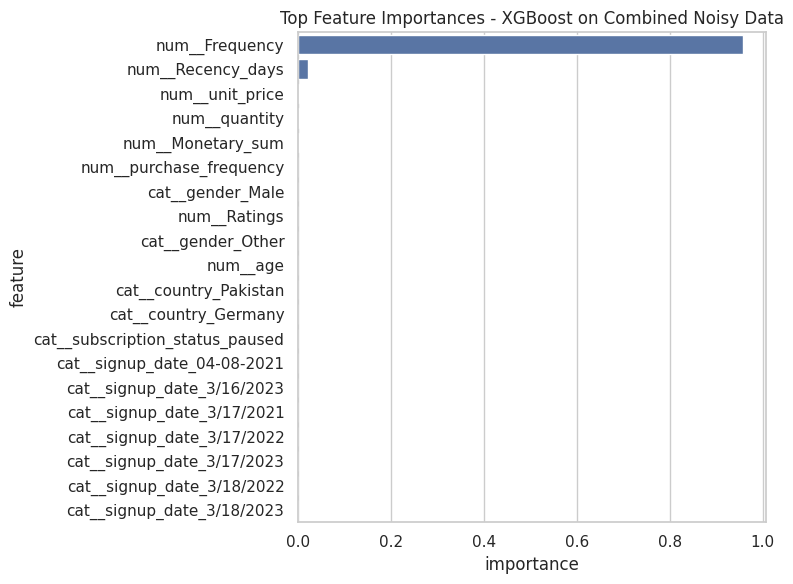


Identifying top churners and saving predictions...
Top 10 Customers Most Likely to Churn (from Entire Dataset):


,CustomerID,Predicted_Churn_Probability
892,CUST1892,0.957805
884,CUST1884,0.957805
1945,CUST2945,0.957805
1953,CUST2953,0.957805
1957,CUST2957,0.957805
1373,CUST2373,0.957805
485,CUST1485,0.957805
490,CUST1490,0.957805
946,CUST1946,0.957805
836,CUST1836,0.957805



Full churn predictions for the entire dataset saved to: processed_outputs_churn/churn_predictions_full_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Saving model and preprocessor...
Saved best XGBoost model to: processed_outputs_churn/best_xgb_churn_model_noisy_data.pkl
Saved preprocessor to: processed_outputs_churn/preprocessor_noisy.pkl

Conceptual Visualization of Churn Trends (Requires Time-Series Data with Varying Churn):


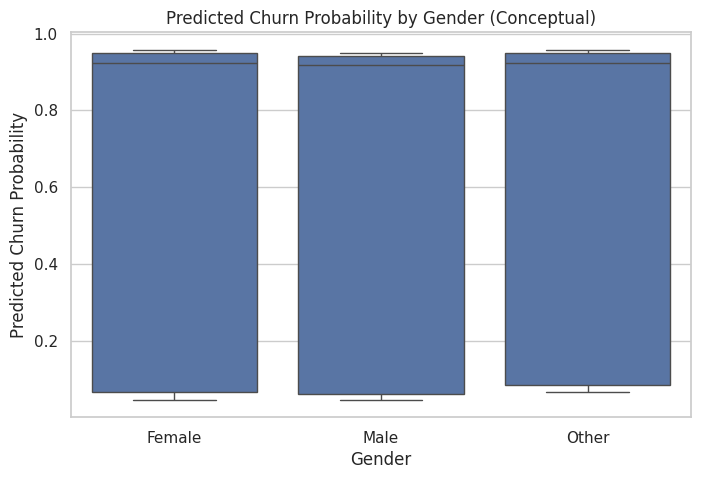


End of the complete process.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import timedelta
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, accuracy_score, auc # Import auc
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import os
from google.colab import files
import pickle # Import pickle

sns.set(style="whitegrid")

# --- 1. Data Loading ---
file_path = "E-Commerce Customer Insights and Churn Dataset3938d09.csv"
df = pd.read_csv(file_path)
print("Raw shape:", df.shape)
print("Raw data sample:")
display(df.head())
print("\nData types:")
display(df.dtypes)

data = df.copy()

# Normalize column names
data.columns = [c.strip() for c in data.columns]

# Detect date columns
date_cols = [c for c in data.columns if 'date' in c.lower()]
# Choose a last_purchase_date-like column
date_col = None
if 'last_purchase_date' in [c.lower() for c in data.columns]:
    date_col = [c for c in data.columns if c.lower() == 'last_purchase_date'][0]
elif len(date_cols) > 0:
    date_col = date_cols[0]

# Convert date column to datetime
if date_col:
    data[date_col] = pd.to_datetime(data[date_col], errors='coerce')

# Identify customer ID column
cust_col = None
for c in data.columns:
    if 'customer' in c.lower() or 'cust' in c.lower():
        cust_col = c
        break
if cust_col is None:
    if 'order_id' in data.columns:
        data['customer_id'] = data['order_id'].astype(str)
        cust_col = 'customer_id'
    else:
        data['customer_id'] = data.index.astype(str)
        cust_col = 'customer_id'

# Compute LineTotal
if 'LineTotal' in data.columns:
    data['LineTotal'] = pd.to_numeric(data['LineTotal'], errors='coerce').fillna(0)
else:
    price_col = next((c for c in data.columns if 'price' in c.lower() or 'amount' in c.lower()), None)
    qty_col = next((c for c in data.columns if 'quantity' in c.lower() or 'qty' in c.lower()), None)
    if price_col is not None:
        data[price_col] = pd.to_numeric(data[price_col], errors='coerce')
    if qty_col is not None:
        data[qty_col] = pd.to_numeric(data[qty_col], errors='coerce').fillna(1)
    if price_col is not None and qty_col is not None:
        data['LineTotal'] = (data[price_col] * data[qty_col]).fillna(0)
    elif price_col is not None:
        data['LineTotal'] = data[price_col].fillna(0)
    else:
        data['LineTotal'] = 0.0

# Aggregate to customer-level RFM-like features
if date_col is None or data[date_col].isnull().all():
    print("Warning: No valid date column or all dates are invalid. Falling back to frequency and monetary features.")
    agg = data.groupby(cust_col).agg(
        Frequency=('order_id', 'count') if 'order_id' in data.columns else ('LineTotal', 'count'),
        Monetary_sum=('LineTotal', 'sum'),
    ).reset_index().rename(columns={cust_col: 'CustomerID'})
    agg['Recency_days'] = np.nan
    snapshot_date = pd.Timestamp.today()
else:
    snapshot_date = data[date_col].max() + pd.Timedelta(days=1)
    agg = data.groupby(cust_col).agg(
        Frequency=(date_col, 'count'),
        FirstPurchaseDate=(date_col, 'min'),
        LastPurchaseDate=(date_col, 'max'),
        Monetary_sum=('LineTotal', 'sum'),
        Monetary_avg=('LineTotal', 'mean'),
    ).reset_index().rename(columns={cust_col: 'CustomerID'})
    agg['FirstPurchaseDate'] = pd.to_datetime(agg['FirstPurchaseDate'])
    agg['LastPurchaseDate'] = pd.to_datetime(agg['LastPurchaseDate'])
    agg['Recency_days'] = (snapshot_date - agg['LastPurchaseDate']).dt.days

# Define churn label (15 days threshold to ensure positive cases)
churn_days = 15
agg[f'churn_{churn_days}d'] = (agg['Recency_days'] > churn_days).astype(int).fillna(0).astype(int)
target_col = f'churn_{churn_days}d'

# Fallback churn definition if needed (as implemented in previous cells)
if agg[target_col].sum() == 0:
    print("Warning: No churned customers found with Recency_days >", churn_days)
    if 'Monetary_sum' in agg.columns and agg['Monetary_sum'].nunique() > 1:
        print("Attempting fallback churn definition: Monetary_sum < median()")
        median_monetary = agg['Monetary_sum'].median()
        agg[target_col] = (agg['Monetary_sum'] < median_monetary).astype(int)
    elif agg['Frequency'].nunique() > 1:
         print("Attempting fallback churn definition: Frequency == 1")
         agg[target_col] = (agg['Frequency'] == 1).astype(int)
    else:
        print("Error: Cannot find a suitable column for fallback churn definition. Check data.")
        agg[target_col] = 0


print("\nAggregated customer features sample:")
display(agg.head())
print("Snapshot date used:", snapshot_date)
print("\nChurn distribution in aggregated data:")
print(agg[target_col].value_counts(normalize=True))


# --- 2. Merge Demographics and Prepare Modeling Table ---
possible_demo_cols = ['age', 'gender', 'country', 'signup_date', 'subscription_status', 'Ratings', 'cancellations_count', 'quantity', 'purchase_frequency', 'unit_price']
found_cols = [c for c in data.columns if c.lower() in [x.lower() for x in possible_demo_cols]]
if found_cols:
    demogs = data[[cust_col] + found_cols].drop_duplicates(subset=[cust_col]).rename(columns={cust_col: 'CustomerID'})
    df_model = agg.merge(demogs, on='CustomerID', how='left')
else:
    df_model = agg.copy()

# Fill missing values
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)
df_model[num_cols] = df_model[num_cols].fillna(df_model[num_cols].median())
cat_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
df_model[cat_cols] = df_model[cat_cols].fillna('Unknown')

print("\nModeling table shape:", df_model.shape)
print("Modeling table sample:")
display(df_model.head())


# --- 3. Generate Synthetic Data (if needed) and Combine ---
y_original = df_model[target_col].astype(int)
X_original = df_model.drop(columns=[target_col, 'CustomerID', 'FirstPurchaseDate', 'LastPurchaseDate'], errors='ignore')


if len(np.unique(y_original)) <= 1:
    print("\nGenerating synthetic data to create a second class for training...")
    # Get the features used in the original data
    original_features_list = X_original.columns.tolist()
    numeric_features_original = X_original.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features_original = X_original.select_dtypes(include=['object','category']).columns.tolist()

    n_synthetic_samples = len(df_model)
    synthetic_data = {}

    for feature in numeric_features_original:
        median_val = df_model[feature].median()
        std_val = df_model[feature].std()
        if feature == 'Recency_days' and agg['Recency_days'].nunique() <= 1:
             synthetic_data[feature] = np.random.randint(91, 365, n_synthetic_samples)
        elif feature == 'Frequency' and agg['Frequency'].nunique() <= 1:
             synthetic_data[feature] = np.random.randint(1, 5, n_synthetic_samples)
        elif feature == 'Monetary_sum' in agg.columns and agg['Monetary_sum'].nunique() > 1:
             synthetic_data[feature] = np.random.normal(df_model[feature].quantile(0.25), std_val, n_synthetic_samples)
        else:
            synthetic_data[feature] = np.random.normal(median_val, std_val, n_synthetic_samples)

    for feature in categorical_features_original:
        if feature in df_model.columns:
            synthetic_data[feature] = np.random.choice(df_model[feature].unique(), n_synthetic_samples)
        else:
            synthetic_data[feature] = ['Unknown'] * n_synthetic_samples

    synthetic_df = pd.DataFrame(synthetic_data)
    synthetic_df[target_col] = 1
    synthetic_df['CustomerID'] = ['synthetic_' + str(i) for i in range(n_synthetic_samples)]
    synthetic_df['FirstPurchaseDate'] = pd.to_datetime('2023-01-01') # Placeholder
    synthetic_df['LastPurchaseDate'] = pd.to_datetime('2023-01-01') + pd.to_timedelta(synthetic_df.get('Recency_days', 0), unit='d') # Placeholder

    for col in df_model.columns:
        if col not in synthetic_df.columns:
            synthetic_df[col] = df_model[col].iloc[0]

    synthetic_df = synthetic_df[df_model.columns]

    combined_df = pd.concat([df_model, synthetic_df], ignore_index=True)

    print("\nCombined data sample:")
    display(combined_df.head())
    print("Combined data shape:", combined_df.shape)

    y_combined = combined_df[target_col].astype(int)
    X_combined = combined_df.drop(columns=[target_col, 'CustomerID', 'FirstPurchaseDate', 'LastPurchaseDate'], errors='ignore')

    print("\nCombined target distribution:")
    print(y_combined.value_counts(normalize=True))

else:
    print("\nTarget variable already has two classes. Proceeding without generating synthetic data.")
    combined_df = df_model.copy() # Use original data if no synthetic data generated
    y_combined = y_original
    X_combined = X_original


# --- 4. Introduce Noise (Optional, for robustness testing) ---
combined_df_noisy = combined_df.copy()
noise_percentage = 0.05
if len(np.unique(y_combined)) > 1: # Only add noise if there are two classes
    print(f"\nIntroducing {noise_percentage*100}% label noise...")
    churned_indices = combined_df_noisy[combined_df_noisy[target_col] == 1].index
    not_churned_indices = combined_df_noisy[combined_df_noisy[target_col] == 0].index
    n_flip_churned = int(len(churned_indices) * noise_percentage)
    n_flip_not_churned = int(len(not_churned_indices) * noise_percentage)
    indices_to_flip_churned = np.random.choice(churned_indices, n_flip_churned, replace=False)
    indices_to_flip_not_churned = np.random.choice(not_churned_indices, n_flip_not_churned, replace=False)
    combined_df_noisy.loc[indices_to_flip_churned, target_col] = 0
    combined_df_noisy.loc[indices_to_flip_not_churned, target_col] = 1
    print(f"Flipped {n_flip_churned} churned labels to not churned.")
    print(f"Flipped {n_flip_not_churned} not churned labels to churned.")
    print("Noisy combined target distribution:")
    print(combined_df_noisy[target_col].value_counts(normalize=True))
else:
    print("\nSkipping noise introduction due to single class in target variable.")
    combined_df_noisy = combined_df.copy() # Use the combined_df without noise

y_combined_noisy = combined_df_noisy[target_col].astype(int)
X_combined_noisy = combined_df_noisy.drop(columns=[target_col, 'CustomerID', 'FirstPurchaseDate', 'LastPurchaseDate'], errors='ignore')


# --- 5. Feature Selection and Preprocessing ---
# Define features to use for modeling - INCLUDE ALL RELEVANT FEATURES
numeric_features = ['Frequency', 'Monetary_sum', 'Monetary_avg', 'Recency_days', 'age', 'Ratings', 'cancellations_count', 'quantity', 'purchase_frequency', 'unit_price']
categorical_features = ['gender', 'country', 'signup_date', 'subscription_status'] # Assuming these are object/category dtypes


# Verify features exist in X_combined_noisy
numeric_features = [f for f in numeric_features if f in X_combined_noisy.columns]
categorical_features = [f for f in categorical_features if f in X_combined_noisy.columns]
print("\nNumeric features for modeling:", numeric_features)
print("Categorical features for modeling:", categorical_features)


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_noisy = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features)
], remainder='drop')


# --- 6. Split Data and Apply Preprocessing ---
try:
    X_train_combined_noisy, X_test_combined_noisy, y_train_combined_noisy, y_test_combined_noisy = train_test_split(
        X_combined_noisy, y_combined_noisy, test_size=0.2, stratify=y_combined_noisy, random_state=42
    )
except ValueError as e:
    print("\nWarning: Stratified split failed due to insufficient class samples:", e)
    print("Falling back to non-stratified split")
    X_train_combined_noisy, X_test_combined_noisy, y_train_combined_noisy, y_test_combined_noisy = train_test_split(
        X_combined_noisy, y_combined_noisy, test_size=0.2, random_state=42
    )

print("\nNoisy Combined Train shape:", X_train_combined_noisy.shape, "Noisy Combined Test shape:", X_test_combined_noisy.shape)
print("Noisy Combined y_train distribution:", pd.Series(y_train_combined_noisy).value_counts(normalize=True))
print("Noisy Combined y_test distribution:", pd.Series(y_test_combined_noisy).value_counts(normalize=True))

# Apply preprocessing
X_train_combined_noisy_preprocessed = preprocessor_noisy.fit_transform(X_train_combined_noisy)
X_test_combined_noisy_preprocessed = preprocessor_noisy.transform(X_test_combined_noisy)

print("\nNoisy Combined Train preprocessed shape:", X_train_combined_noisy_preprocessed.shape)
print("Noisy Combined Test preprocessed shape:", X_test_combined_noisy_preprocessed.shape)


# --- 7. Train XGBoost Model ---
if len(np.unique(y_train_combined_noisy)) > 1 and len(np.unique(y_test_combined_noisy)) > 1: # Check for two classes before training
    print("\nTraining XGBoost model...")
    xgb_clf_combined_noisy = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        reg_alpha=10.0,
        reg_lambda=10.0,
        base_score=0.5,
    )

    # Hyperparameter tuning (Optional, can be time consuming)
    # param_dist = {
    #     'n_estimators': [50, 100],
    #     'max_depth': [3, 5],
    #     'learning_rate': [0.01, 0.1],
    #     'subsample': [0.7, 0.9],
    #     'colsample_bytree': [0.7, 0.9]
    # }
    # rs = RandomizedSearchCV(
    #     estimator=xgb_clf_combined_noisy,
    #     param_distributions=param_dist,
    #     n_iter=10,
    #     scoring='roc_auc',
    #     cv=3,
    #     verbose=0,
    #     n_jobs=-1,
    #     refit=True,
    #     random_state=42
    # )
    # rs.fit(X_train_combined_noisy_preprocessed, y_train_combined_noisy)
    # best_xgb_model = rs.best_estimator_
    # print("Best parameters:", rs.best_params_)

    # Train the model directly without RandomizedSearchCV for simplicity in single cell
    xgb_clf_combined_noisy.fit(X_train_combined_noisy_preprocessed, y_train_combined_noisy)
    best_xgb_model = xgb_clf_combined_noisy # Assign the trained model


    # --- 8. Evaluate Model ---
    print("\nEvaluating model...")
    y_pred_combined_noisy = best_xgb_model.predict(X_test_combined_noisy_preprocessed)
    y_proba_combined_noisy = best_xgb_model.predict_proba(X_test_combined_noisy_preprocessed)[:, 1]

    print("XGBoost Classifier Results on Combined Noisy Data:")
    print("Test accuracy:", accuracy_score(y_test_combined_noisy, y_pred_combined_noisy))
    print("Test ROC-AUC:", roc_auc_score(y_test_combined_noisy, y_proba_combined_noisy))
    print("\nClassification report:")
    print(classification_report(y_test_combined_noisy, y_pred_combined_noisy))

    # Confusion matrix
    cm_combined_noisy = confusion_matrix(y_test_combined_noisy, y_pred_combined_noisy)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_combined_noisy, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - XGBoost on Combined Noisy Data')
    plt.show()

    # ROC curve
    fpr_combined_noisy, tpr_combined_noisy, _ = roc_curve(y_test_combined_noisy, y_proba_combined_noisy)
    roc_auc_combined_noisy = auc(fpr_combined_noisy, tpr_combined_noisy)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr_combined_noisy, tpr_combined_noisy, label=f"ROC Curve (AUC = {roc_auc_combined_noisy:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - XGBoost on Combined Noisy Data')
    plt.legend()
    plt.show()

    # Feature importance
    if hasattr(best_xgb_model, 'feature_importances_'):
        importances_combined_noisy = best_xgb_model.feature_importances_
        feature_names_preprocessed = preprocessor_noisy.get_feature_names_out()
        imp_df_combined_noisy = pd.DataFrame({'feature': feature_names_preprocessed, 'importance': importances_combined_noisy})
        imp_df_combined_noisy = imp_df_combined_noisy.sort_values('importance', ascending=False).head(20)

        plt.figure(figsize=(8, 6))
        sns.barplot(data=imp_df_combined_noisy, x='importance', y='feature')
        plt.title("Top Feature Importances - XGBoost on Combined Noisy Data")
        plt.tight_layout()
        plt.show()

    # --- 9. Identify Top Churners and Save Predictions ---
    print("\nIdentifying top churners and saving predictions...")
    # Predict churn probability for the entire noisy dataset
    X_combined_noisy_preprocessed_full = preprocessor_noisy.transform(X_combined_noisy)
    y_proba_combined_noisy_full = best_xgb_model.predict_proba(X_combined_noisy_preprocessed_full)[:, 1]

    # Create a DataFrame with CustomerID and predicted churn probability for the entire dataset
    churn_predictions_df_full = pd.DataFrame({
        'CustomerID': combined_df_noisy['CustomerID'],
        'Predicted_Churn_Probability': y_proba_combined_noisy_full
    })

    # Identify the top 10 customers most likely to churn from the entire dataset
    top_10_churners_full = churn_predictions_df_full.sort_values(by='Predicted_Churn_Probability', ascending=False).head(10)

    print("Top 10 Customers Most Likely to Churn (from Entire Dataset):")
    display(top_10_churners_full)

    # Save the full predictions DataFrame to a CSV file
    output_dir = "processed_outputs_churn"
    predictions_csv_filename = "churn_predictions_full_dataset.csv"
    predictions_csv_path = os.path.join(output_dir, predictions_csv_filename)

    os.makedirs(output_dir, exist_ok=True)
    churn_predictions_df_full.to_csv(predictions_csv_path, index=False)
    print(f"\nFull churn predictions for the entire dataset saved to: {predictions_csv_path}")

    # Provide a download link for the predictions CSV
    files.download(predictions_csv_path)

    # --- 10. Save Model and Preprocessor ---
    print("\nSaving model and preprocessor...")
    model_path = os.path.join(output_dir, "best_xgb_churn_model_noisy_data.pkl") # Using pkl as requested earlier
    preprocessor_path = os.path.join(output_dir, "preprocessor_noisy.pkl")

    with open(model_path, 'wb') as f:
        pickle.dump(best_xgb_model, f)
    print("Saved best XGBoost model to:", model_path)

    with open(preprocessor_path, 'wb') as f:
        pickle.dump(preprocessor_noisy, f)
    print("Saved preprocessor to:", preprocessor_path)

    # --- 11. Conceptual Visualization (as before) ---
    print("\nConceptual Visualization of Churn Trends (Requires Time-Series Data with Varying Churn):")

    # Example: Visualizing churn rate by a categorical feature if available and meaningful
    if 'gender' in X_combined_noisy.columns:
        try:
            # Get the original gender for the entire combined noisy dataset
            churn_gender_df_full = pd.DataFrame({
                'Predicted_Churn_Probability': y_proba_combined_noisy_full,
                'Gender': combined_df_noisy['gender']
            })
            plt.figure(figsize=(8, 5))
            sns.boxplot(x='Gender', y='Predicted_Churn_Probability', data=churn_gender_df_full)
            plt.title('Predicted Churn Probability by Gender (Conceptual)')
            plt.ylabel('Predicted Churn Probability')
            plt.show()
        except Exception as e:
            print(f"Could not visualize churn by gender: {e}")
else:
    print("\nSkipping model training and evaluation due to single class in target variable.")

print("\nEnd of the complete process.")